# <div style="text-align: center;">*IRIS  FLOWER  CLASSIFICATION.*</div>

# PHASE 1 - EDA.

- # DATA EXPLORATION.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset

df = pd.read_csv('../datasets/Iris.csv')

In [3]:
# let's explore the dataset

print('                                                   TOP 5 ROWS OF THE DATASET\n'                               )
print(df.head())
print('\n                                                   BOTTOM 5 ROWS OF THE DATASET\n'                               )
print(df.tail())
print('\n                                                   DATASET INFORMATION\n'                               )
print(df.info())
print('\n                                                   DATASET DESCRIPTION\n'                               )
print(df.describe())
print('\n                                                   DATASET SHAPE\n'                               )
print(df.shape)





                                                   TOP 5 ROWS OF THE DATASET

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

                                                   BOTTOM 5 ROWS OF THE DATASET

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9     

# key insights from the above exploration:
- The dataset contains 150 rows and 6 columns.
- The dataset contains 4 numerical features and 1 categorical feature.
- The dataset contains 3 classes of iris flowers: Setosa, Versicolor, and Virginica.
- The dataset is balanced, with 50 samples for each class.
- The dataset contains 4 numerical features: SepalLengthCm, SepalWidthCm, PetalLengthCm, and PetalWidthCm.
- The dataset contains 1 categorical feature: Species.
- The dataset is clean and ready for analysis and modeling.

In [4]:
# let's drop the 'id' column as it is not useful for our analysis.
df.drop('Id', axis=1, inplace=True)

In [ ]:
# Let's check for missing values and duplicates in the dataset.

print('\n                                                   MISSING VALUES IN THE DATASET\n'                               )
print(df.isnull().sum())
print('\n                                                   DUPLICATE VALUES IN THE DATASET\n'                               )
print('duplicated values:',df.duplicated().sum())
duplicates = df[df.duplicated(keep=False)]
print("Duplicate rows:")
print(duplicates)
print("\nIndex of duplicate rows:")
print(duplicates.index)
print('\n                                                   AFTER REMOVING DUPLICATES VALUES\n'                               )
print(df.drop_duplicates(inplace=True))
print('Duplicated values after removing duplicates:',df.duplicated().sum())


                                                   MISSING VALUES IN THE DATASET

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

                                                   DUPLICATE VALUES IN THE DATASET

duplicated values: 3
Duplicate rows:
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
9              4.9           3.1            1.5           0.1     Iris-setosa
34             4.9           3.1            1.5           0.1     Iris-setosa
37             4.9           3.1            1.5           0.1     Iris-setosa
101            5.8           2.7            5.1           1.9  Iris-virginica
142            5.8           2.7            5.1           1.9  Iris-virginica

Index of duplicate rows:
Index([9, 34, 37, 101, 142], dtype='int64')

                                                   AFTER REMOVING DUPLICATES VALUES

None
Duplicated values after removing duplicates: 0


# key insigts from the above exploration:

- There are no missing values in the dataset.
- There are 3 species of iris flowers in the dataset: Iris-setosa, Iris-versicolor, and Iris-virginica.
- The dataset contains duplicate values which have been removed.
- The dataset contains different values for the categorical column 'Species' which can be used for classification.
  

In [32]:
# Let's check value counts of categorical columns in the dataset.
print('\n                                                   VALUE COUNTS OF CATEGORICAL COLUMNS IN THE DATASET\n'                               )
print(df['Species'].value_counts())



                                                   VALUE COUNTS OF CATEGORICAL COLUMNS IN THE DATASET

Species
Iris-versicolor    49
Iris-virginica     49
Iris-setosa        45
Name: count, dtype: int64


- # DATA VISUALIZATION. 

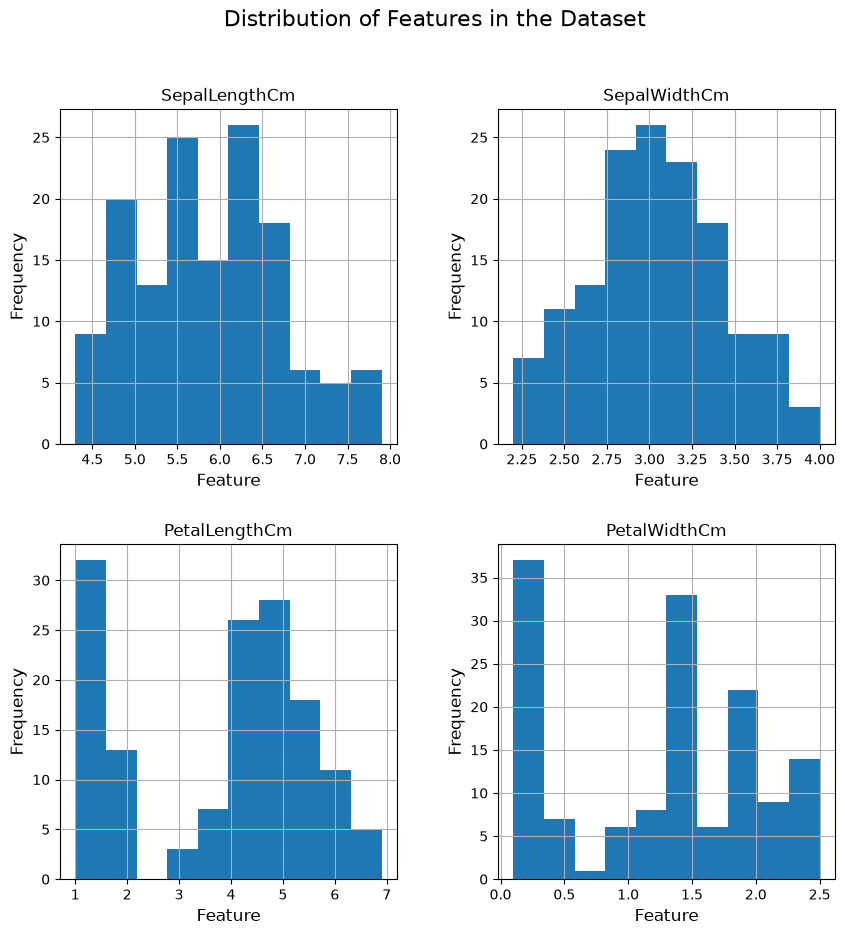

In [33]:
# Let's visualize the distribution of the features in the dataset using histograms.
df.hist(figsize=(10, 10))
plt.suptitle('Distribution of Features in the Dataset', fontsize=16)
# set x and y axis labels for each subplot
for ax in plt.gcf().axes:
    ax.set_ylabel('Frequency', fontsize=12)  
    ax.set_xlabel('Feature', fontsize=12)

<Axes: >

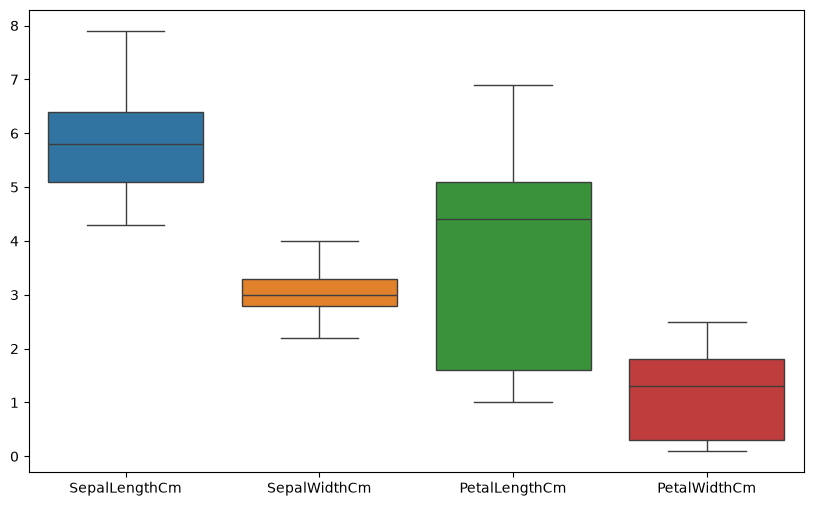

In [34]:
# let's check for any outiers

plt.figure(figsize=(10, 6))
sns.boxplot(data=df)

<Axes: >

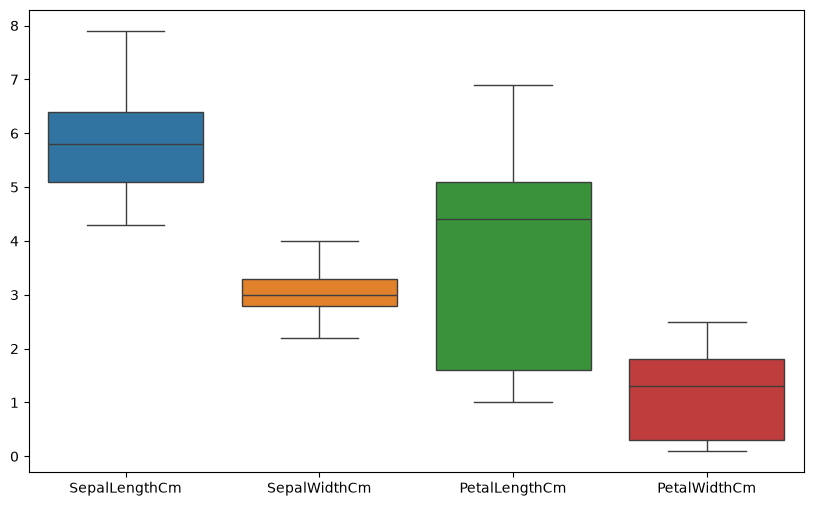

In [9]:
Q1 = df['SepalWidthCm'].quantile(0.25)
Q3 = df['SepalWidthCm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['SepalWidthCm'] >= lower) & (df['SepalWidthCm'] <= upper)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df)

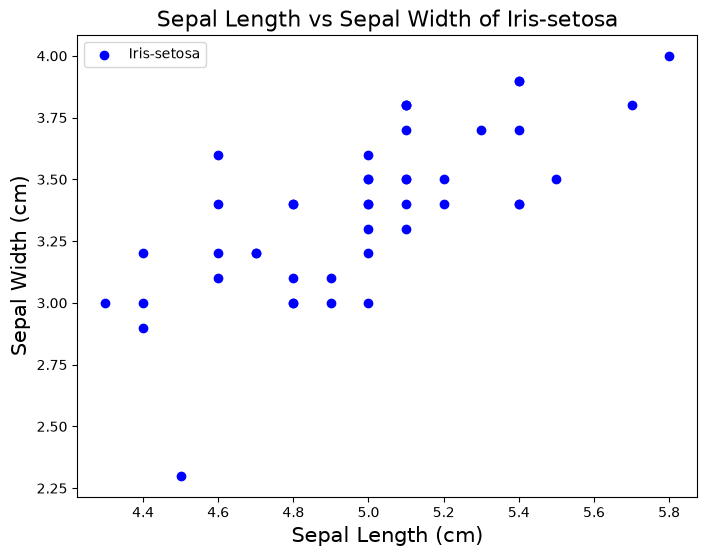

In [35]:
# let's visualize the relationship between Sepal Length and Sepal Width for each species using scatter plots.
setosa = df[df['Species'] == 'Iris-setosa']
plt.figure(figsize=(8, 6))
plt.scatter(setosa['SepalLengthCm'], setosa['SepalWidthCm'], color='blue', label='Iris-setosa')
plt.title('Sepal Length vs Sepal Width of Iris-setosa', fontsize=16)
plt.xlabel('Sepal Length (cm)', fontsize=15)
plt.ylabel('Sepal Width (cm)', fontsize=15)
plt.legend()

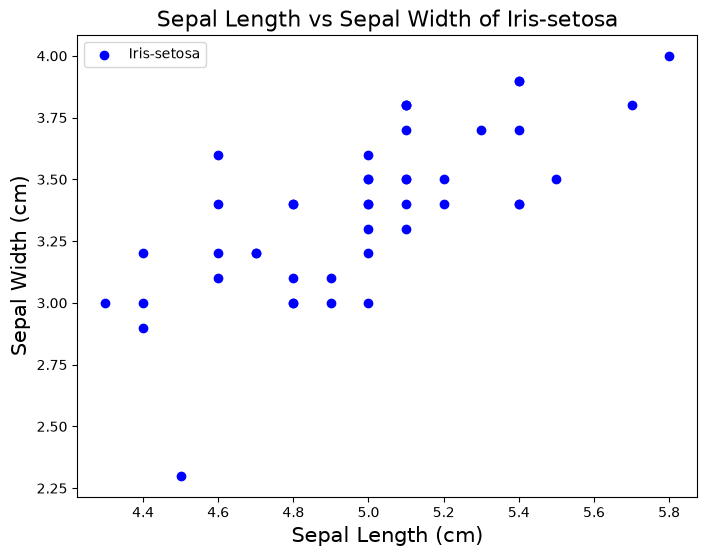

In [36]:
# let's visualize the relationship between Sepal Length and Sepal Width for each species using scatter plots.
plt.figure(figsize=(8, 6))
plt.scatter(setosa['SepalLengthCm'], setosa['SepalWidthCm'], color='blue', label='Iris-setosa')
plt.title('Sepal Length vs Sepal Width of Iris-setosa', fontsize=16)
plt.xlabel('Sepal Length (cm)', fontsize=15)
plt.ylabel('Sepal Width (cm)', fontsize=15)
plt.legend()

Axes(0.125,0.11;0.775x0.77)


<function matplotlib.pyplot.show(close=None, block=None)>

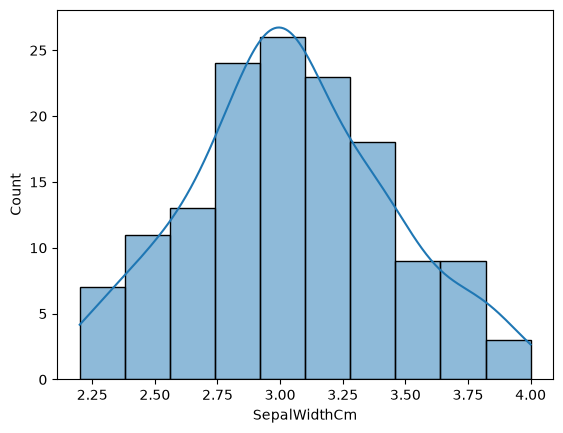

In [37]:
# let's see whether the dataset is normally distributed or not

print(sns.histplot(df['SepalWidthCm'], kde=True))
plt.show

Axes(0.125,0.11;0.775x0.77)


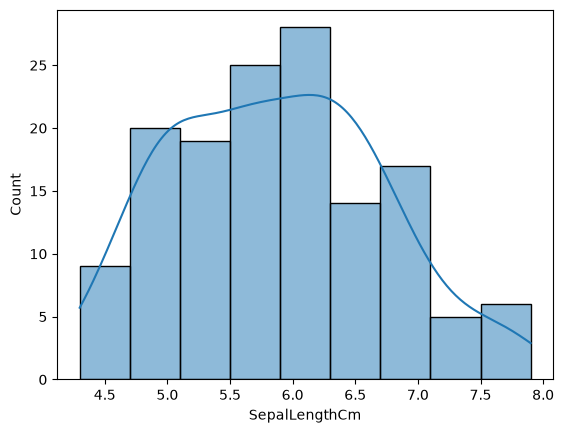

In [38]:
print(sns.histplot(df['SepalLengthCm'], kde=True))


Axes(0.125,0.11;0.775x0.77)


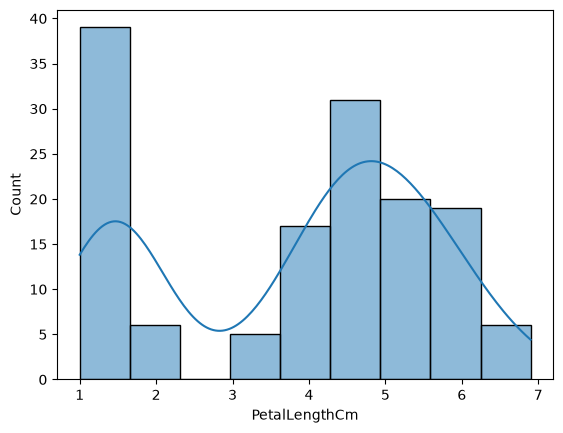

In [39]:
print(sns.histplot(df['PetalLengthCm'],  kde=True))


Axes(0.125,0.11;0.775x0.77)


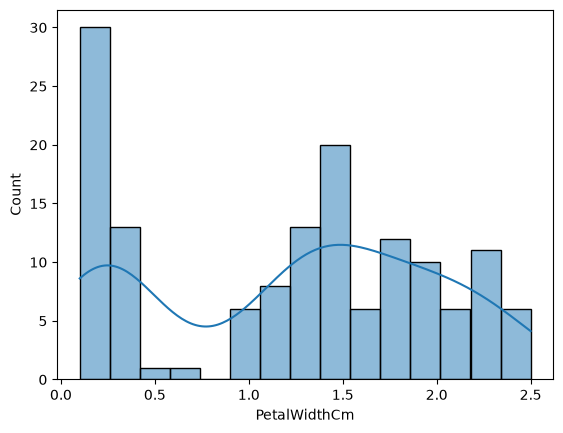

In [40]:
print(sns.histplot(df['PetalWidthCm'], bins=15, kde=True))


In [16]:
from scipy.stats import shapiro 

num_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm' ]
for col in num_cols:
    stat, p = shapiro(df[col])
    print(col)
    print('p-value', p)
    if p > 0.05:
        print('Approx norm distributed')
    else:
        print('Not norm distributed')    

SepalLengthCm
p-value 0.014154599917513824
Not norm distributed
SepalWidthCm
p-value 0.06069119552306363
Approx norm distributed
PetalLengthCm
p-value 1.1387507186538429e-09
Not norm distributed
PetalWidthCm
p-value 2.6713977003125425e-08
Not norm distributed


- # Save the data

In [41]:
df.to_csv('cleaned_iris.csv', index=False)